# Data Preprocessing Lab: Getting Data ML-Ready

## Student Practice Notebook

**Name:** B.GNAYNASINDHU
**Register Number:** AP24110011847
**Date:** 21/08/2026

## Learning Objectives

After completing this lab, you will be able to:

- Handle missing data with justified strategies (not just delete-everything)
- Encode categorical variables into numeric form (label encoding, one-hot encoding)
- Scale/normalize numeric features (min-max scaling, standardization)
- Detect and handle outliers
- Split data into train/test sets correctly
- Apply preprocessing to image data (pixel normalization) and text data (numeric encoding)

### Why this week matters
Every ML model needs **numbers, on a similar scale, with no gaps**. Raw pandas data (mixed types, missing values, unscaled numbers) can't go directly into a model. This lab is the bridge between "clean data" (last week) and "model-ready data" (next steps in your course).

### How to use this notebook
Same as before: **demo → practice → predict-then-run → reflect.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


## Part 1: Missing Data — Choosing a Strategy

Last week you dropped or filled missing values without much thought about *which* to choose. This week: which strategy is right depends on the situation.

### Demonstration


In [2]:
tips_missing = tips.copy()
np.random.seed(42)
missing_idx = np.random.choice(tips_missing.index, size=15, replace=False)
tips_missing.loc[missing_idx, 'total_bill'] = np.nan

print("Missing values:", tips_missing['total_bill'].isna().sum())
print("Percentage missing: {:.1f}%".format(100 * tips_missing['total_bill'].isna().sum() / len(tips_missing)))


Missing values: 15
Percentage missing: 6.1%


**Common strategies:**
- **Drop rows** — safe when missing % is small AND rows are random (not systematically missing)
- **Fill with mean/median** — good for numeric columns; median is safer when outliers exist
- **Fill with mode** — for categorical columns
- **Fill with group-wise mean** — smarter: fill using the mean *within a relevant group* instead of the global mean

### Demonstration: group-wise fill (smarter than global mean)


In [3]:
# Instead of filling with the overall mean, fill using each day's own mean
# This preserves day-to-day differences instead of flattening everything to one number

day_means = tips_missing.groupby('day')['total_bill'].transform('mean')
tips_filled = tips_missing.copy()
tips_missing_filled_bill = tips_missing['total_bill'].fillna(day_means)
tips_filled['total_bill'] = tips_missing_filled_bill

print("Remaining missing:", tips_filled['total_bill'].isna().sum())


Remaining missing: 0


### Student Practice

1. Create missing values in the `tip` column (5 random rows) the same way as the demo.
2. Fill them using the **median** `tip` grouped by `time` (Lunch/Dinner) instead of by day.
3. In 1-2 sentences, justify why you chose group-by-`time` over a global fill for this column.


In [5]:
# Create 5 random missing values in tip
tips_missing = tips.copy()

np.random.seed(42)
missing_idx = np.random.choice(tips_missing.index, size=5, replace=False)
tips_missing.loc[missing_idx, 'tip'] = np.nan

print("Missing values:", tips_missing['tip'].isna().sum())
print("Percentage missing: {:.1f}%".format(
    100 * tips_missing['tip'].isna().sum() / len(tips_missing)
))

# Fill missing tip values using median grouped by time
time_medians = tips_missing.groupby('time')['tip'].transform('median')

tips_filled = tips_missing.copy()
tips_filled['tip'] = tips_missing['tip'].fillna(time_medians)

print("Remaining missing:", tips_filled['tip'].isna().sum())

Missing values: 5
Percentage missing: 2.0%
Remaining missing: 0


**Reflection:** Why might filling missing values with a *group-wise* mean/median be better than a single global mean? Give a concrete scenario where this would matter.

*Your answer:*
Grouping by time preserves differences in tipping behavior between Lunch and Dinner. It is more appropriate than a global median because each time group gets a value representative of its own tipping pattern.

## Part 2: Encoding Categorical Variables

ML models need numbers — they can't use `"Male"`, `"Sun"`, `"Yes"` directly. We need to **encode** categories into numeric form.

### 2a. Label Encoding (for ordinal/binary categories)

### Demonstration


In [6]:
tips_enc = tips.copy()

# Binary categories: map directly to 0/1
tips_enc['sex_encoded'] = tips_enc['sex'].map({'Male': 0, 'Female': 1})
tips_enc['smoker_encoded'] = tips_enc['smoker'].map({'No': 0, 'Yes': 1})

tips_enc[['sex','sex_encoded','smoker','smoker_encoded']].head()


,sex,sex_encoded,smoker,smoker_encoded
0,Female,1,No,0
1,Male,0,No,0
2,Male,0,No,0
3,Male,0,No,0
4,Female,1,No,0


### 2b. One-Hot Encoding (for categories with no natural order)

`day` has 4 categories with no inherent ranking (Thur isn't "less than" Fri). Label encoding (0,1,2,3) would wrongly imply an order. **One-hot encoding** creates a separate 0/1 column per category instead.

### Demonstration


In [7]:
day_dummies = pd.get_dummies(tips_enc['day'], prefix='day')
tips_enc = pd.concat([tips_enc, day_dummies], axis=1)
tips_enc[['day','day_Thur','day_Fri','day_Sat','day_Sun']].head()


,day,day_Thur,day_Fri,day_Sat,day_Sun
0,Sun,False,False,False,True
1,Sun,False,False,False,True
2,Sun,False,False,False,True
3,Sun,False,False,False,True
4,Sun,False,False,False,True


### Student Practice — predict then check

`time` has 2 categories (Lunch, Dinner). Predict: should you use label encoding or one-hot encoding for `time`, and why? Write your prediction, then implement whichever you chose.

*Your prediction:* i willl use one-hot encoding becaose time consits of onlyt two lunch or dinner it is easy to represnt and understand by using binary numbers instaed of unique numbers so, i prefer one -hot label encoding


In [8]:
# Write your answer here
tips_encoded = pd.get_dummies(tips, columns=['time'])

print(tips_encoded.head())


   total_bill   tip     sex smoker  day  size  tip_pct  time_Dinner  \
0       16.99  1.01  Female     No  Sun     2    0.059         True   
1       10.34  1.66    Male     No  Sun     3    0.161         True   
2       21.01  3.50    Male     No  Sun     3    0.167         True   
3       23.68  3.31    Male     No  Sun     2    0.140         True   
4       24.59  3.61  Female     No  Sun     4    0.147         True   

   time_Lunch  
0       False  
1       False  
2       False  
3       False  
4       False  


**Reflection:** Why would label-encoding `day` as Thur=0, Fri=1, Sat=2, Sun=3 be misleading to a model, even though it's technically valid Python code?

*Your answer:*
AS we know that ml model think like if the wiight of the faetyure is high the more prefernce should be given for that it tinks that sundy is hgraeter then other daya but we haven t given the label encoding for thoise days in that way we just use some random numbers without impaortance.

## Part 3: Feature Scaling

`total_bill` ranges roughly 3-50, while `tip_pct` ranges roughly 0-1. Many ML algorithms (e.g. distance-based ones like KNN, or gradient-based ones) perform poorly when features are on very different scales — a large-range feature can dominate just because of its scale, not because it's more important.

### 3a. Min-Max Scaling (rescales to a fixed 0-1 range)

### Demonstration


In [9]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

tips_enc['total_bill_scaled'] = min_max_scale(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_scaled']].describe()


,total_bill,total_bill_scaled
count,244.000,244.000
mean,19.786,0.350
std,8.902,0.186
min,3.070,0.000
25%,13.348,0.215
50%,17.795,0.308
75%,24.127,0.441
max,50.810,1.000


### 3b. Standardization (rescales to mean=0, std=1)

### Demonstration


In [10]:
def standardize(series):
    return (series - series.mean()) / series.std()

tips_enc['total_bill_standardized'] = standardize(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_standardized']].describe()


,total_bill,total_bill_standardized
count,244.000,2.440e+02
mean,19.786,-6.029e-17
std,8.902,1.000e+00
min,3.070,-1.878e+00
25%,13.348,-7.232e-01
50%,17.795,-2.236e-01
75%,24.127,4.877e-01
max,50.810,3.485e+00


### Student Practice — predict then check

Predict: after standardizing, what will the **mean** of `total_bill_standardized` be (approximately)? What about the standard deviation? Write your prediction, then verify with `.mean()` and `.std()`.

*Your prediction:*

Now apply **min-max scaling** to the `size` column and store it as `size_scaled`.


In [11]:
# Write your answer here
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

tips['total_bill_standardized'] = scaler.fit_transform(
    tips[['total_bill']]
)

print("Mean:", tips['total_bill_standardized'].mean())
print("Standard deviation:", tips['total_bill_standardized'].std())

Mean: -7.871663248366888e-17
Standard deviation: 1.0020555006273097


In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

tips['size_scaled'] = scaler.fit_transform(
    tips[['size']]
)

print(tips[['size', 'size_scaled']].head())

   size  size_scaled
0     2          0.2
1     3          0.4
2     3          0.4
3     2          0.2
4     4          0.6


**Reflection:** In your own words, what's the difference between min-max scaling and standardization? When might you prefer one over the other? (Hint: think about what happens to each with extreme outliers.)

*Your answer:* min max change the range of the feature values between 0 to 1.standardization makes teh mean around zero and calculate using standard deviation
i wold prefer min max when the range of the features isvery large and stabdardiztion when the range is low.

## Part 4: Outlier Detection and Handling

Outliers are unusually extreme values that can distort model training. A common rule: values beyond **1.5 × IQR** (interquartile range) from Q1/Q3 are considered outliers.

### Demonstration


In [13]:
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = tips[(tips['total_bill'] < lower_bound) | (tips['total_bill'] > upper_bound)]
print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of outliers: {len(outliers)}")
outliers[['total_bill','day','size']]


Bounds: [-2.82, 40.30]
Number of outliers: 9


,total_bill,day,size
59,48.27,Sat,4
102,44.30,Sat,3
142,41.19,Thur,5
156,48.17,Sun,6
170,50.81,Sat,3
182,45.35,Sun,3
184,40.55,Sun,2
197,43.11,Thur,4
212,48.33,Sat,4


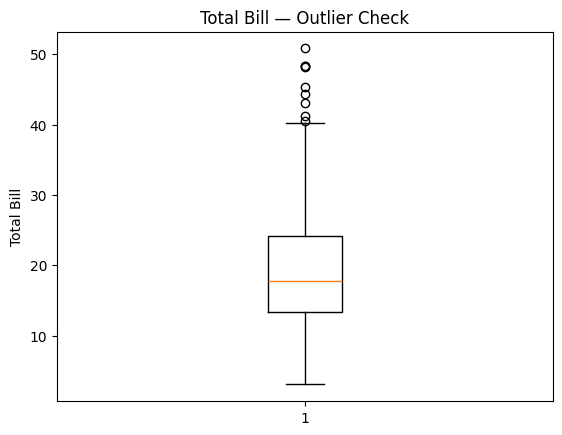

In [14]:
# Visualize outliers with a boxplot
plt.figure()
plt.boxplot(tips['total_bill'])
plt.title("Total Bill — Outlier Check")
plt.ylabel("Total Bill")
plt.show()


### Student Practice

1. Run the same IQR outlier check on the `tip` column.
2. Instead of dropping outliers, **cap** them: replace any value above `upper_bound` with `upper_bound` itself, and any value below `lower_bound` with `lower_bound` (this is called "capping" or "winsorizing" — it keeps the row but limits the extreme value).


In [15]:
# Write your answer here
# Calculate Q1 and Q3
Q1 = tips['tip'].quantile(0.25)
Q3 = tips['tip'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Count outliers before capping
outliers_before = (
    (tips['tip'] < lower_bound) |
    (tips['tip'] > upper_bound)
).sum()

print("Outliers before capping:", outliers_before)

# Cap (winsorize) the outliers
tips_capped = tips.copy()

tips_capped['tip'] = tips_capped['tip'].clip(
    lower=lower_bound,
    upper=upper_bound
)

# Count outliers after capping
outliers_after = (
    (tips_capped['tip'] < lower_bound) |
    (tips_capped['tip'] > upper_bound)
).sum()

print("Outliers after capping:", outliers_after)


Lower bound: -0.34375
Upper bound: 5.90625
Outliers before capping: 9
Outliers after capping: 0


**Reflection:** Why might capping outliers be preferable to simply dropping those rows? When would dropping be the better choice instead?

*Your answer:*if we remove the row because of outlier we may lose sometime an useful information so insted of losing teh information we convert that outlier value into small value within the range of non outliers by using some techniques
so we use capping to save data.


## Part 5: Train/Test Split

Before training any model, data must be split so we can test performance on data the model has never seen. Splitting **after** all the preprocessing above ensures both sets are equally clean and encoded.

### Demonstration


In [16]:
from sklearn.model_selection import train_test_split

X = tips_enc[['total_bill_scaled','size','sex_encoded','smoker_encoded']]
y = tips_enc['tip_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (195, 4)
Test shape: (49, 4)


### Student Practice

1. Redo the split with `test_size=0.3` instead of 0.2. How many rows end up in the test set now?
2. Why do we set `random_state=42` (or any fixed number)? What would change if you removed it and ran the split twice?


In [17]:
# Write your answer here
from sklearn.model_selection import train_test_split

X = tips.drop('tip', axis=1)
y = tips['tip']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 170
Testing rows: 74


In [ ]:
random helps to get the smae rows fro testing and training for each split if we cahneg the random nuebr for ecah split it takes differnt rows whivh efftcts on training and training

**Reflection:** Why is it important to split data **before** the model ever sees the test set, rather than training on all the data at once?

*Your answer:*
if we train all the teat and train data then we dont know how ell or accyarate taht ml models give answers foir new data.

# Mini Project A: Image Preprocessing Pipeline (Image Track)

Raw image pixel values (0-255) are rarely fed directly into a model — they're almost always normalized first. You'll now apply real preprocessing to the images from your Week 2 mini-project.

## Step 1: Normalize pixel values

### Demonstration


In [21]:
from google.colab import files
uploaded = files.upload()


Saving Screenshot 2026-08-26 095103.png to Screenshot 2026-08-26 095103.png
Saving Screenshot 2026-08-26 095115.png to Screenshot 2026-08-26 095115.png
Saving Screenshot 2026-08-26 095220.png to Screenshot 2026-08-26 095220.png


In [22]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
sample_name = filenames[0]
img_array = np.array(Image.open(sample_name))

print("Original pixel range:", img_array.min(), "-", img_array.max())
print("Original dtype:", img_array.dtype)

# Normalize to 0-1 range (standard preprocessing step before feeding into a CNN)
img_normalized = img_array / 255.0

print("Normalized pixel range:", img_normalized.min(), "-", img_normalized.max())
print("Normalized dtype:", img_normalized.dtype)


Original pixel range: 0 - 255
Original dtype: uint8
Normalized pixel range: 0.0 - 1.0
Normalized dtype: float64


### Student Practice

1. Normalize **all** your uploaded images (loop over `filenames`) and store each normalized array in a list.
2. Build a small pandas DataFrame with columns `filename`, `min_pixel_before`, `max_pixel_before`, `min_pixel_after`, `max_pixel_after` to confirm normalization worked correctly across all images.


In [23]:
# Write your answer here
filenames = list(uploaded.keys())

normalized_images = []
results = []

for filename in filenames:
    img_array = np.array(Image.open(filename))

    # Normalize from 0–255 to 0–1
    img_normalized = img_array / 255.0

    normalized_images.append(img_normalized)

    results.append({
        'filename': filename,
        'min_pixel_before': img_array.min(),
        'max_pixel_before': img_array.max(),
        'min_pixel_after': img_normalized.min(),
        'max_pixel_after': img_normalized.max()
    })

df_check = pd.DataFrame(results)

print(df_check)

                           filename  min_pixel_before  max_pixel_before  \
0  Screenshot 2026-08-26 095103.png                 0               255   
1  Screenshot 2026-08-26 095115.png                 0               255   
2  Screenshot 2026-08-26 095220.png                 0               255   

   min_pixel_after  max_pixel_after  
0              0.0              1.0  
1              0.0              1.0  
2              0.0              1.0  


## Step 2: Resize images to a consistent shape

Models need every input image to be the **same size**. Your uploaded images likely have different dimensions. Resizing standardizes this.

### Demonstration


In [24]:
target_size = (128, 128)

img_pil = Image.open(sample_name)
img_resized = img_pil.resize(target_size)
img_resized_array = np.array(img_resized)

print("Original shape:", img_array.shape)
print("Resized shape:", img_resized_array.shape)


Original shape: (438, 621, 4)
Resized shape: (128, 128, 4)


### Student Practice

Resize all your uploaded images to `(128, 128)`, normalize each to 0-1, and confirm every resulting array has the exact same shape using a pandas DataFrame (columns: `filename`, `shape`).


In [26]:
from PIL import Image
import numpy as np
import pandas as pd
import os

image_paths = [
    "Screenshot 2026-08-26 095103.png",
    "Screenshot 2026-08-26 095115.png",
    "Screenshot 2026-08-26 095220.png"
]

results = []

for path in image_paths:
    # Open image and resize to 128 × 128
    img = Image.open(path).convert("RGB")
    img = img.resize((128, 128))

    # Convert to NumPy array and normalize pixels to 0–1
    arr = np.array(img, dtype=np.float32) / 255.0

    results.append({
        "filename": os.path.basename(path),
        "shape": arr.shape
    })

# Create DataFrame
df = pd.DataFrame(results)

df

,filename,shape
0,Screenshot 2026-08-26 095103.png,"(128, 128, 3)"
1,Screenshot 2026-08-26 095115.png,"(128, 128, 3)"
2,Screenshot 2026-08-26 095220.png,"(128, 128, 3)"


**Reflection:** Why must every image fed into a model have the exact same shape? What would happen if you tried to feed images of different sizes into the same model?
If we feed images of different sizes into a model, the array dimensions will be different for each image, which can lead to an error. To fix this, the images should be resized or padded to the same shape.

# Mini Project B: Text Preprocessing Pipeline (NLP Track)

Just like images, raw text needs preprocessing before a model can use it: cleaning, and converting words into numeric IDs (since bag-of-words counts alone aren't how most modern NLP pipelines represent text).

## Step 1: Text cleaning

### Demonstration


In [27]:
raw_text = "NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day."

# Cleaning steps: lowercase, remove punctuation, tokenize
import re

cleaned = raw_text.lower()
cleaned = re.sub(r'[^a-z0-9\s]', '', cleaned)  # remove punctuation
tokens = cleaned.split()

print("Before:", raw_text)
print("After:", tokens)


Before: NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day.
After: ['numpy', 'pandas', 'and', 'scikitlearn', 'are', 'amazing', 'tools', 'i', 'use', 'numpy', 'every', 'day']


### Student Practice

Write your own messy sentence (include punctuation, capital letters, maybe a number). Clean it using the same pattern and print the resulting tokens.


In [29]:
# Write your answer here
text = "Hello, I am Sindhu!"

# Clean the text
cleaned_text = text.lower().replace(",", "").replace("!", "")

# Split into tokens
tokens = cleaned_text.split()

print(tokens)


['hello', 'i', 'am', 'sindhu']


## Step 2: Encoding words as numeric IDs

Models need numbers, not words. We'll build a **word-to-ID mapping** (a simple form of what's called a "vocabulary index" — the first step toward embeddings).

### Demonstration


In [30]:
vocabulary = sorted(set(tokens))
word_to_id = {word: idx for idx, word in enumerate(vocabulary)}

print("Word to ID mapping:", word_to_id)

encoded_tokens = [word_to_id[word] for word in tokens]
print("Original tokens:", tokens)
print("Encoded as IDs:  ", encoded_tokens)


Word to ID mapping: {'am': 0, 'hello': 1, 'i': 2, 'sindhu': 3}
Original tokens: ['hello', 'i', 'am', 'sindhu']
Encoded as IDs:   [1, 2, 0, 3]


### Student Practice

1. Build a `word_to_id` mapping for the tokens from your Step 1 sentence.
2. Encode your tokens into a list of numeric IDs.
3. Build a pandas DataFrame with columns `word` and `id` showing the full mapping, sorted by `id`.


In [31]:
# Write your answer here
import pandas as pd

# Build word-to-ID mapping
word_to_id = {word: i for i, word in enumerate(tokens)}

# Encode tokens into numeric IDs
encoded_tokens = [word_to_id[word] for word in tokens]

print("Word to ID mapping:", word_to_id)
print("Encoded tokens:", encoded_tokens)

# Create DataFrame
df = pd.DataFrame(
    list(word_to_id.items()),
    columns=["word", "id"]
).sort_values("id")

df



Word to ID mapping: {'hello': 0, 'i': 1, 'am': 2, 'sindhu': 3}
Encoded tokens: [0, 1, 2, 3]


,word,id
0,hello,0
1,i,1
2,am,2
3,sindhu,3


**Reflection:** This word-to-ID encoding is similar to label encoding from Part 2. What potential problem could this cause if fed directly into a model (Hint: think about the "misleading order" issue from Part 2 — does the same issue apply to words)?

*Your answer:*
Yes, the same misleading order problem applies to words. Assigning numbers to words can make the model think that one word has a higher or lower value than another, even though words do not have a natural numerical order. This can lead to incorrect assumptions by the model.

# Final Self-Check

- [ ] I handled missing data using a justified strategy, not just dropped everything blindly
- [ ] I correctly chose label encoding vs one-hot encoding based on whether categories have order
- [ ] I scaled numeric features and can explain the difference between min-max and standardization
- [ ] I detected outliers using IQR and handled them (capped, not just deleted)
- [ ] I split data into train/test sets correctly
- [ ] I completed Mini Project A (image normalization/resizing) or B (text cleaning/encoding)
- [ ] I answered all reflection questions in my own words

## Final Reflection Questions

1. Put the preprocessing steps in this lab in the order you'd typically apply them to a raw dataset, and briefly justify the order.

2. Why is preprocessing considered part of "data work," and not something a model does automatically?

3. Compare preprocessing images (Mini Project A) vs preprocessing text (Mini Project B). What's conceptually similar between normalizing pixels and encoding words as IDs?

4. What's one preprocessing concept from this lab you still feel unsure about? Be specific.
